In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Sample_Superstore.csv", encoding="latin1")

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
#creating new data features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day
df["Day Name"] = df["Order Date"].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Day,Day Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,4,8,Tuesday
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,4,8,Tuesday
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,2,12,Sunday
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,4,11,Sunday
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,4,11,Sunday


In [3]:
#calculating shipping time
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [4]:
#shipping statistics
df["Shipping Days"].describe()

,Shipping Days
count,9994.000000
mean,3.958175
std,1.747567
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [5]:
#detect outliers (sales)
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Sales"] < lower) | (df["Sales"] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 1167


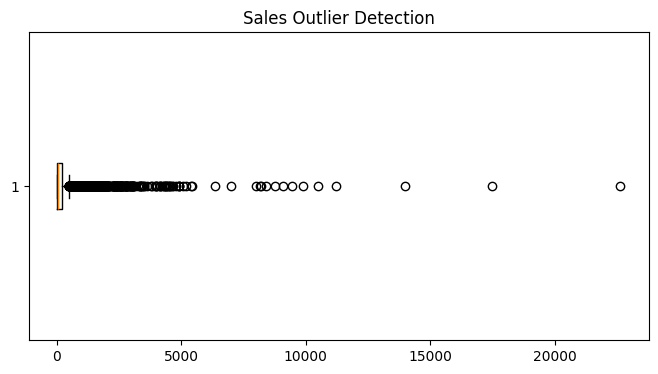

In [6]:
#visualizing outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.boxplot(df["Sales"], vert=False)

plt.title("Sales Outlier Detection")

plt.show()

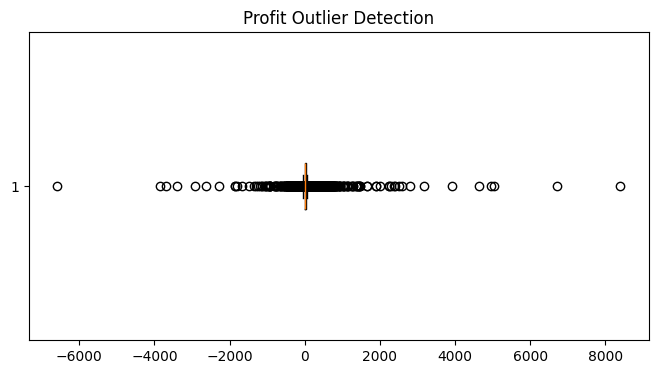

In [7]:
#profit outliers
plt.figure(figsize=(8,4))

plt.boxplot(df["Profit"], vert=False)

plt.title("Profit Outlier Detection")

plt.show()

In [8]:
#save the cleaned dataset
df.to_csv("Cleaned_Superstore.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
